### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [40]:
Total_Facturacion = list([sum (tienda.Precio), sum(tienda2.Precio), sum(tienda3.Precio), sum(tienda4.Precio)])
Tiendas = ["tienda", "tienda2", "tienda3", "tienda4"]
print(Total_Facturacion)

[1150880400.0, 1116343500.0, 1098019600.0, 1038375700.0]


In [42]:
Total_Facturacion


[1150880400.0, 1116343500.0, 1098019600.0, 1038375700.0]

In [3]:
from matplotlib import pyplot as plt

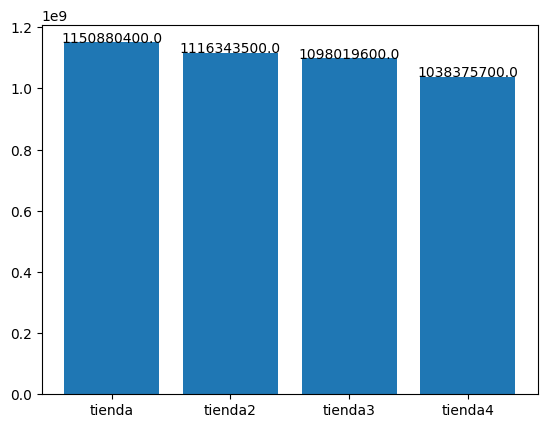

In [4]:
plt.bar(x= Tiendas, height=Total_Facturacion)

for i, Total_Facturacion in enumerate(Total_Facturacion):
    plt.text(i, Total_Facturacion + 1.3, str(Total_Facturacion), ha='center')

plt.show()

# 2. Ventas por categoría

In [5]:
from typing import Counter
def contar_categoria (x):
  Contar= Counter (x["Categoría del Producto"])
  return Contar

def contar_comun (x):
  Contar= Counter (x["Categoría del Producto"])
  Comun= Contar.most_common(1)
  return Comun

In [43]:
Total_Categorias= list([contar_categoria (tienda), contar_categoria (tienda2), contar_categoria (tienda3), contar_categoria (tienda4)])
print (Total_Categorias)

[Counter({'Muebles': 465, 'Electrónicos': 448, 'Juguetes': 324, 'Electrodomésticos': 312, 'Deportes y diversión': 284, 'Instrumentos musicales': 182, 'Libros': 173, 'Artículos para el hogar': 171}), Counter({'Muebles': 442, 'Electrónicos': 422, 'Juguetes': 313, 'Electrodomésticos': 305, 'Deportes y diversión': 275, 'Instrumentos musicales': 224, 'Libros': 197, 'Artículos para el hogar': 181}), Counter({'Muebles': 499, 'Electrónicos': 451, 'Juguetes': 315, 'Electrodomésticos': 278, 'Deportes y diversión': 277, 'Libros': 185, 'Instrumentos musicales': 177, 'Artículos para el hogar': 177}), Counter({'Muebles': 480, 'Electrónicos': 451, 'Juguetes': 338, 'Deportes y diversión': 277, 'Electrodomésticos': 254, 'Artículos para el hogar': 201, 'Libros': 187, 'Instrumentos musicales': 170})]


In [44]:
categoria_comun = list([contar_comun (tienda), contar_comun (tienda2), contar_comun (tienda3), contar_comun (tienda4)])
print (categoria_comun)

[[('Muebles', 465)], [('Muebles', 442)], [('Muebles', 499)], [('Muebles', 480)]]


# 3. Calificación promedio de la tienda


In [8]:
from os import truncate
def cali_prom (x):
  calculo = round((sum(x.Calificación))/(len(x)),2)
  return calculo



In [45]:
Calificaciones = list([cali_prom(tienda), cali_prom(tienda2), cali_prom(tienda3), cali_prom(tienda4)])
print (Calificaciones)

[3.98, 4.04, 4.05, 4.0]


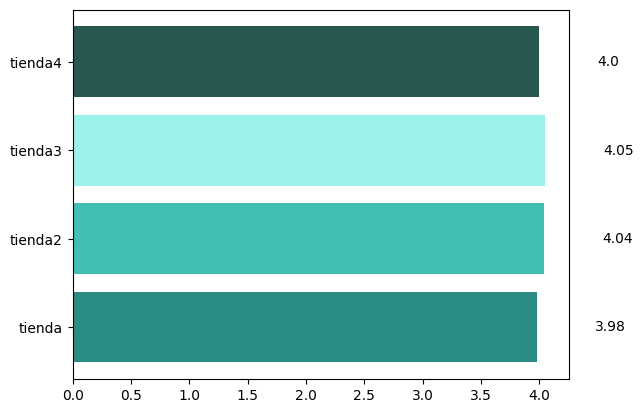

In [10]:
colores= ["#2A8C82", "#41BFB3", "#9BF2EA", "#275950"]
plt.barh(Tiendas, Calificaciones, color=colores)
for i, Calificaciones in enumerate(Calificaciones):
    plt.text(Calificaciones + 0.5, i, str(Calificaciones), va='center')

# 4. Productos más y menos vendidos

In [11]:
def prod_max(x):
  Contador=Counter (x["Producto"])
  mas= Contador.most_common(1)
  return mas

def prod_menos(x):
  Contador=Counter (x["Producto"])
  Menos_Comun= Contador.most_common()[-1]
  return Menos_Comun


In [51]:
producto_mas= (prod_max(tienda), prod_max(tienda2), prod_max(tienda3), prod_max(tienda4))
print (producto_mas)

([('Microondas', 60)], [('Iniciando en programación', 65)], [('Kit de bancas', 57)], [('Cama box', 62)])


In [13]:
producto_menos=(prod_menos(tienda), prod_menos(tienda2), prod_menos(tienda3), prod_menos(tienda4))
print (producto_menos)

(('Celular ABXY', 33), ('Juego de mesa', 32), ('Bloques de construcción', 35), ('Guitarra eléctrica', 33))


# 5. Envío promedio por tienda

In [14]:
def env_prom (x):
  calculo = round((sum(x["Costo de envío"]))/(len(x)),2)
  return calculo

In [15]:
env_prom(tienda)

26018.61

In [68]:
Envios_totales = [env_prom(tienda), env_prom(tienda2), env_prom(tienda3), env_prom(tienda4)]
print (Envios_totales)

[26018.61, 25216.24, 24805.68, 23459.46]


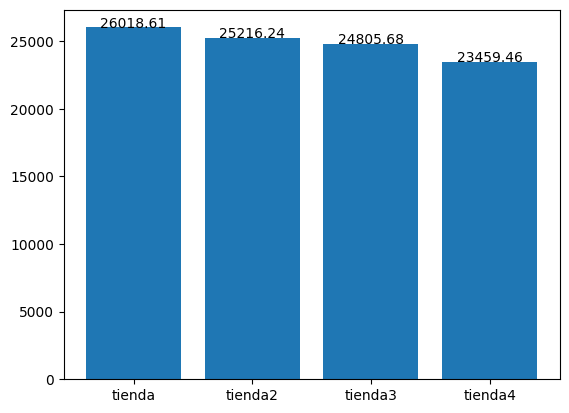

In [66]:
plt.bar(x= Tiendas, height=Envios_totales)

for i, Envios_totales in enumerate(Envios_totales):
    plt.text(i, Envios_totales + 1.3, str(Envios_totales), ha='center')

plt.show()

# 6. Analisis

la mayor categoria de ventas en todas las tiendas fueron los muebles.

Se analizará la situación de la tienda 1 y la tienda 4, esto debido a que la tienda 1 a pesar de tener los mayores ingresos también cuenta con los costos de envios mas altos ademas de la peor calificacion de las 4 tiendas; por otro lado la tienda 4 tiene ingresos menores también lo son sus costos de envios.

In [59]:
Total_Facturacion[0], Total_Facturacion[3]

(1150880400.0, 1038375700.0)

In [63]:
diferencia_ingresos= (Total_Facturacion [0] - Total_Facturacion[3])
print (diferencia_ingresos)

112504700.0


In [69]:
diferencia_costos= (Envios_totales[0] - Envios_totales[3])
print (diferencia_costos)

2559.1500000000015


In [71]:
ingresos_tienda=(Total_Facturacion[0] - Envios_totales[0])
print (ingresos_tienda)

1150854381.39


In [76]:
ingresos_tienda2=(Total_Facturacion[1] - Envios_totales[1])
print (ingresos_tienda2)

1116318283.76


In [75]:
ingresos_tienda3=(Total_Facturacion[2] - Envios_totales[2])
print (ingresos_tienda3)

1097994794.32


In [72]:
ingresos_tienda4=(Total_Facturacion[3] - Envios_totales[3])
print (ingresos_tienda4)

1038352240.54


# 7. Recomendaciones

la tienda 4 es la mejor opción para ser vendida, sin embargo, también se deben mejorar aspectos en la tienda 1 especificamente el área de servicio al cliente debido a que tiene la peor calificación de las 4 tiendas.
